In [42]:
import xarray as xr, netCDF4 as nc, numpy as np, pandas as pd, os
from pathlib import Path

import dask
import dask.array as da
from dask.distributed import LocalCluster, Client

from scipy.ndimage import label, find_objects
from scipy.sparse import csr_array
from scipy.sparse.csgraph import connected_components

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [ ]:
os.chdir('/g/data/ng72/ms5578/ID_HW_BARRA')
working_dir = Path().absolute()

file_path = '/scratch/ng72/ms5578/hw_files'
write_path = f"{working_dir}/data/output"

In [3]:
mask = xr.open_dataarray("/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/land_sea_mask.nc").astype(bool)

yr_file = f"{file_path}/HW_EHF_2018_2019.nc"
EHF_ds = xr.open_dataset(yr_file,
                         engine='netcdf4')
EHF_ds

<xarray.Dataset> Size: 8GB
Dimensions:      (time: 365, lat: 646, lon: 1082)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2018-07-01T12:00:00 ... 2019-06-30...
  * lat          (lat) float64 5kB -57.97 -57.86 -57.75 ... 12.76 12.87 12.98
  * lon          (lon) float64 9kB 88.48 88.59 88.7 88.81 ... 207.2 207.3 207.4
    height       float64 8B ...
    crs          int32 4B ...
Data variables:
    tas          (time, lat, lon) float64 2GB ...
    EHF_flag     (lat, lon, time) float64 2GB ...
    HW_EHF_avg   (lat, lon, time) float64 2GB ...
    HW_EHF_peak  (lat, lon, time) float64 2GB ...

Using 26 connectivity, following Reddy, Perkins-Kirkpatrick, Sharples (2019)

In [11]:
EHF_flags = EHF_ds.EHF_flag.values

structure = np.ones((3, 3, 3), dtype=int)

event_arr, tot_events = label(EHF_flags, structure=structure)

# Filtering <10 voxel heatwaves
component_sizes = np.bincount(event_arr.ravel())[1:]
valid_components = np.isin(event_arr, np.where(component_sizes >= 50)[0] + 1)
event_arr = event_arr * valid_components
tot_events = len(np.unique(event_arr))

EHF_ds = EHF_ds.assign(events=(['lat','lon','time'], event_arr))

In [12]:
tot_events = len(np.unique(event_arr))
tot_events

130

In [9]:
# component_sizes = np.bincount(event_arr.ravel())[1:]

# # Plot histogram of component sizes
# plt.hist(component_sizes, bins=[0, 10, 20, 50, 100, 200, 500, 1000], edgecolor='black')
# plt.title("Histogram of Connected Component Sizes")
# plt.xlabel("Component Size (voxels)")
# plt.ylabel("Frequency")
# plt.show()

In [13]:
events = EHF_ds.events

In [15]:
from matplotlib.colors import LinearSegmentedColormap

# Define a custom continuous colormap with many colors
colors = ['white', 'blue', 'cyan', 'green', 'yellow', 'orange', 'red', 'purple', 'black']
cmap = LinearSegmentedColormap.from_list("custom_cmap", colors, N=1024)

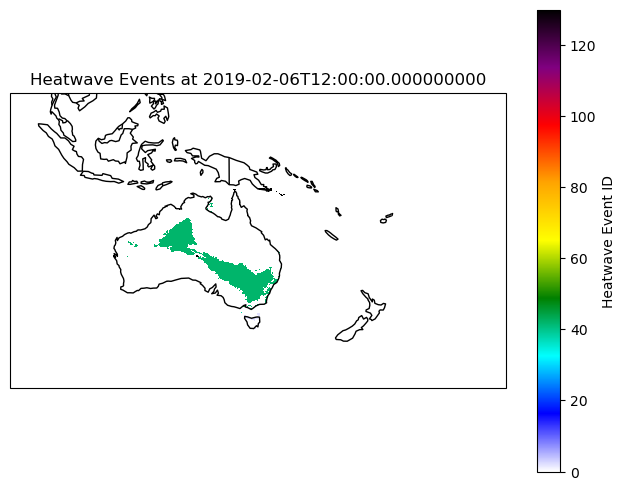

In [ ]:
def plot_hw():
    lon_min, lon_max = EHF_ds.coords['lon'].values.min(), EHF_ds.coords['lon'].values.max()
    lat_min, lat_max = EHF_ds.coords['lat'].values.min(), EHF_ds.coords['lat'].values.max()
    print(lon_min,lon_max,lat_min,lat_max)

    # Set up the figure and axis with Cartopy projection
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    # Plot coastline and borders
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)

    # Choose a specific time step
    time_index = 220
    labeled_at_time = events.isel(time=time_index)

    # Get lat/lon coordinates from the DataArray
    lons = events.lon
    lats = events.lat

    # Create the meshgrid if needed
    lon2d, lat2d = np.meshgrid(lons, lats)

    # Plot using pcolormesh
    c = ax.pcolormesh(lon2d,
                    lat2d,
                    labeled_at_time,
                    cmap=cmap,
                    vmin=0,
                    vmax=tot_events,
                    shading='auto',
                    transform=ccrs.PlateCarree())

    # Add color bar
    plt.colorbar(c, ax=ax, label="Heatwave Event ID")
    plt.title(f"Heatwave Events at {events.coords['time'][time_index].values.astype(str)}")

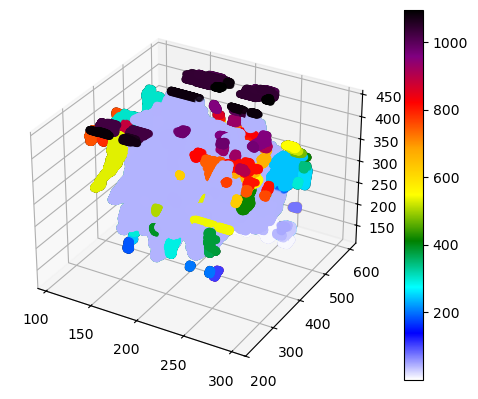

In [40]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Get the coordinates of non-zero points (components)
dim3_arr = np.transpose(event_arr)
x, y, z = np.nonzero(dim3_arr)

# Scatter plot of the labeled components
ax.scatter(x, y, z, c=dim3_arr[x, y, z], cmap=cmap, marker='o', vmin=0, vmax=tot_events)

# Add colorbar
plt.colorbar(ax.scatter(x, y, z, c=dim3_arr[x, y, z], cmap=cmap, marker='o'))

plt.show()

In [95]:
def extract_labeled_objects_strict(arr, mask=None):
    """
    Returns (label_id, slice, values) for exactly `num_features` objects,
    matching the order and count from `label()`.
    """
    if mask is None:
        mask = arr > 0

    labeled, num_features = label(mask)
    slices = find_objects(labeled)

    # Use only the first `num_features` non-None slices
    results = []
    count = 0
    for label_id, sl in enumerate(slices, start=1):
        if sl is not None:
            values = arr[sl]
            results.append((label_id, sl, values))
            count += 1
        if count == num_features:
            break  # Stop once we reach expected number of objects

    return results

In [94]:
slices = find_objects(events)

for obj_id, sl in enumerate(slices, start=1):
    if sl is  None:
        continue
    else:
        sub_array = events[:,:,sl[2]]
        sdate = pd.to_datetime(sub_array.time.values[0]).strftime("%Y-%m-%d")
        edate = pd.to_datetime(sub_array.time.values[-1]).strftime("%Y-%m-%d")
        dirname = f"HW_{sdate}_{edate}_ID_{obj_id}"
        dirpath = f"{write_path}/{dirname}"
        os.makedirs(dirpath)


In [ ]:
results = extract_labeled_objects_strict(EHF_ds.EHF_flag.values)
len(results)

2080

Big purple heatwave lasts 133 days (from day 140)